# Telco Customer Churn Prediction — Case Study
**Course:** AA DSS110  |  **Dataset:** IBM Telco Customer Churn (Kaggle: `blastchar/telco-customer-churn`)  |  **Task:** Supervised binary classification (Churn = Yes / No)

This notebook follows the six required steps: (1) collect data, (2) preprocess and clean with EDA, (3) know the target variable, (4) train a model, (5) evaluate the model, (6) predict on unseen data. The effort is weighted toward Exploratory Data Analysis.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, classification_report)

sns.set_theme(style='whitegrid', context='notebook')
PAL = {'No': '#4C78A8', 'Yes': '#E45756'}
FIG = 'figures'; os.makedirs(FIG, exist_ok=True)
def save(name): plt.tight_layout(); plt.savefig(f'{FIG}/{name}.png', dpi=150, bbox_inches='tight')
RS = 42

## Step 1 — Collect data
The IBM Telco Customer Churn dataset (originally IBM sample data, distributed on Kaggle) is a **classification** dataset, matching the chosen problem type. Each row is one customer; the target is `Churn`.

In [2]:
df_raw = pd.read_csv('Telco-Customer-Churn.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Step 2 — Preprocess and clean data
### 2.1 Data quality audit

In [4]:
print('Duplicate rows:', df_raw.duplicated().sum(), '| duplicate customerIDs:', df_raw.customerID.duplicated().sum())
print('Null values:', df_raw.isna().sum().sum())
# TotalCharges is stored as text -> look for non-numeric entries
bad = df_raw[pd.to_numeric(df_raw.TotalCharges, errors='coerce').isna()]
print('Non-numeric TotalCharges rows:', len(bad))
bad[['customerID','tenure','MonthlyCharges','TotalCharges','Churn']]

Duplicate rows: 0 | duplicate customerIDs: 0
Null values: 0
Non-numeric TotalCharges rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Finding:** `TotalCharges` is an `object` column because 11 rows contain a blank string. All 11 have `tenure = 0` (brand-new customers who have not been billed yet), so the true total is 0, not a random missing value.

### 2.2 Data wrangling

In [5]:
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
df['TotalCharges'] = df['TotalCharges'].fillna(0)            # tenure == 0 -> nothing billed yet
df = df.drop(columns='customerID')                            # identifier, no predictive value
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
# 'No internet service' / 'No phone service' duplicate information already held in InternetService / PhoneService
for c in ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']:
    df[c] = df[c].replace({'No internet service': 'No', 'No phone service': 'No'})
df['ChurnFlag'] = (df.Churn == 'Yes').astype(int)
print(df.shape); print('Missing after cleaning:', df.isna().sum().sum())
df.head()

(7043, 21)
Missing after cleaning: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,No,No,No,45,No,No,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


### 2.3 Outlier check (IQR rule)

In [6]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']
rows = []
for c in num_cols:
    q1, q3 = df[c].quantile([.25,.75]); iqr = q3-q1
    n = ((df[c] < q1-1.5*iqr) | (df[c] > q3+1.5*iqr)).sum()
    rows.append((c, q1-1.5*iqr, q3+1.5*iqr, n))
pd.DataFrame(rows, columns=['feature','lower_fence','upper_fence','n_outliers'])

,feature,lower_fence,upper_fence,n_outliers
0,tenure,-60.000,124.000,0
1,MonthlyCharges,-46.025,171.375,0
2,TotalCharges,-4683.525,8868.675,0


No feature has IQR outliers. The values are bounded and plausible (tenure 0–72 months, monthly charge about \$18–\$119), so **no rows are removed**. The only column dropped is `customerID`.

## Step 3 — Know your target variable

       count  percent
Churn                
No      5174    73.46
Yes     1869    26.54


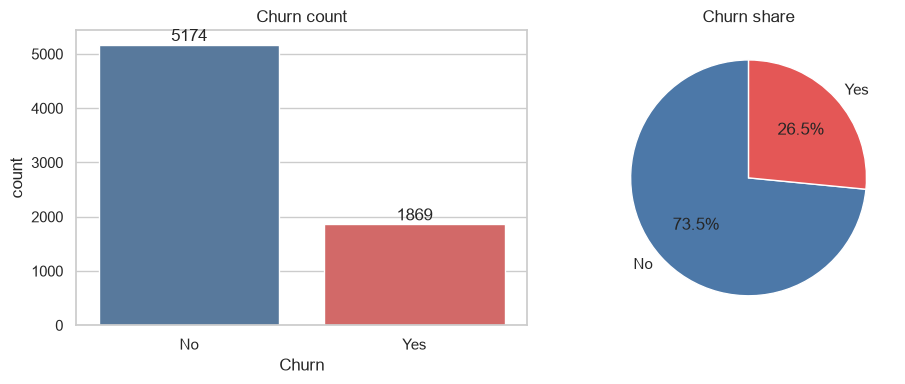

In [7]:
vc = df.Churn.value_counts(); pct = df.Churn.value_counts(normalize=True)*100
print(pd.DataFrame({'count': vc, 'percent': pct.round(2)}))
fig, ax = plt.subplots(1, 2, figsize=(10,4))
sns.countplot(x='Churn', data=df, palette=PAL, ax=ax[0]); ax[0].set_title('Churn count')
for p in ax[0].patches: ax[0].annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
ax[1].pie(vc, labels=vc.index, autopct='%1.1f%%', colors=[PAL[i] for i in vc.index], startangle=90); ax[1].set_title('Churn share')
save('01_target')

`Churn` is binary and **imbalanced (~73.5% No / ~26.5% Yes)**. A model that always predicts "No" would score ~73.5% accuracy while catching zero churners, so accuracy alone is misleading. We therefore (a) use a **stratified** split, (b) apply **class weighting**, and (c) judge models on precision, recall, F1 and ROC-AUC.

## Step 2 (continued) — Exploratory Data Analysis

### EDA 1 — Summary statistics

In [8]:
display(df[num_cols].describe().T.round(2))
display(df.groupby('Churn')[num_cols].agg(['mean','median']).round(2))

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80


tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

### EDA 2 — Numeric features vs churn

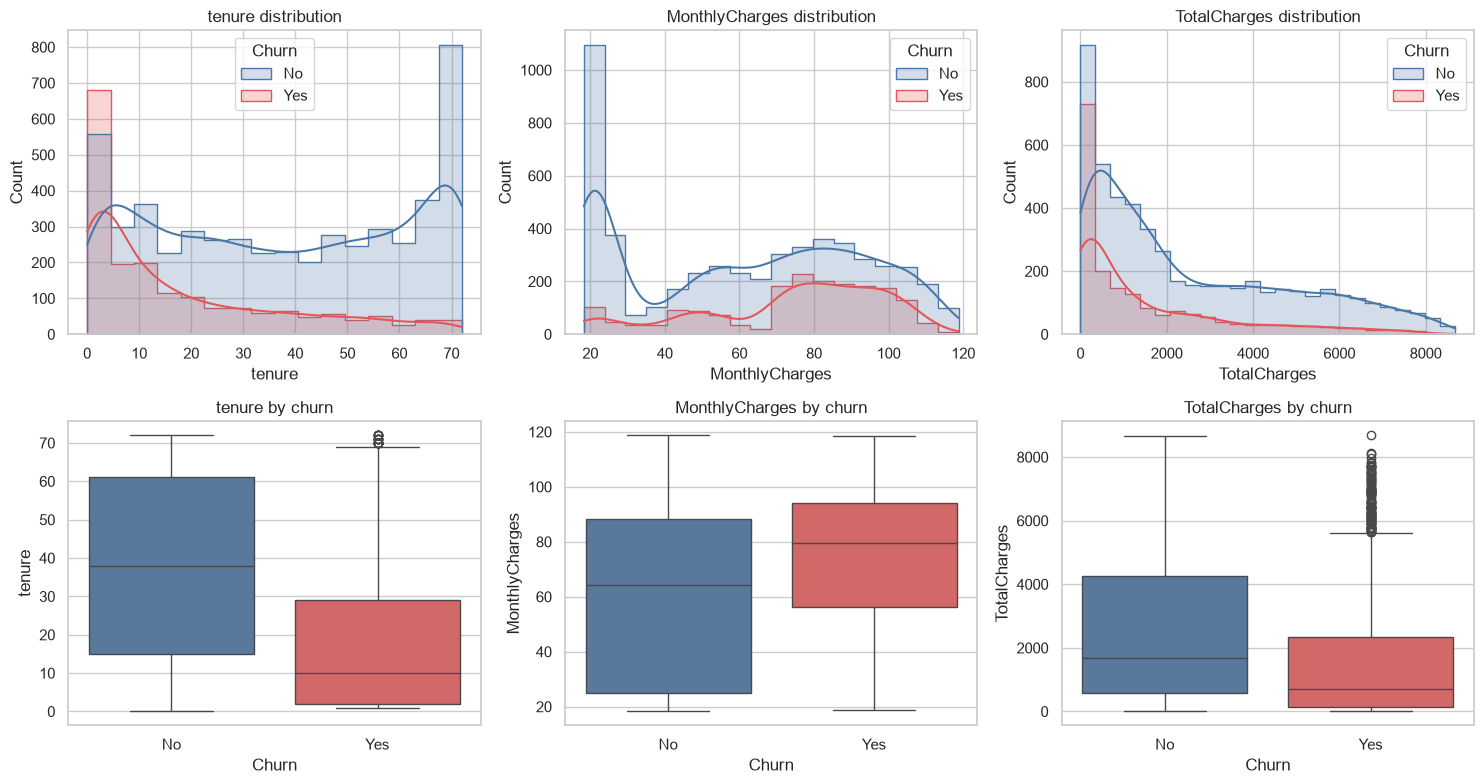

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(15,8))
for i, c in enumerate(num_cols):
    sns.histplot(data=df, x=c, hue='Churn', kde=True, palette=PAL, element='step', ax=ax[0,i]); ax[0,i].set_title(f'{c} distribution')
    sns.boxplot(data=df, x='Churn', y=c, palette=PAL, ax=ax[1,i]); ax[1,i].set_title(f'{c} by churn')
save('02_numeric')

In [10]:
# Mann-Whitney U: do churners and non-churners differ on each numeric feature?
for c in num_cols:
    a, b = df.loc[df.Churn=='Yes', c], df.loc[df.Churn=='No', c]
    u, p = stats.mannwhitneyu(a, b)
    print(f'{c:15s} median churn={a.median():8.2f}  median stay={b.median():8.2f}  p={p:.2e}')

tenure          median churn=   10.00  median stay=   38.00  p=2.42e-208
MonthlyCharges  median churn=   79.65  median stay=   64.43  p=3.31e-54
TotalCharges    median churn=  703.55  median stay= 1679.53  p=5.69e-83


Churners have a much **shorter tenure** (median far below stayers), pay **higher monthly charges**, and accumulate lower total charges (a consequence of leaving early). All differences are statistically significant.

### EDA 3 — Tenure bands and churn

TenureBand
0-12     47.4
13-24    28.7
25-48    20.4
49-60    14.4
61-72     6.6
Name: ChurnFlag, dtype: float64

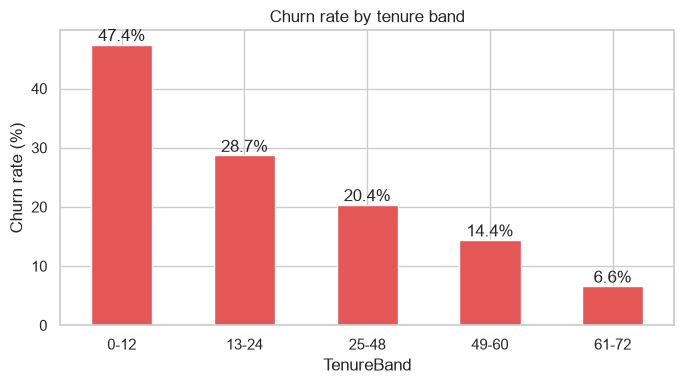

In [11]:
df['TenureBand'] = pd.cut(df.tenure, [-1,12,24,48,60,72], labels=['0-12','13-24','25-48','49-60','61-72'])
tb = df.groupby('TenureBand')['ChurnFlag'].mean().mul(100)
ax = tb.plot(kind='bar', color='#E45756', figsize=(7,4)); ax.set_ylabel('Churn rate (%)'); ax.set_title('Churn rate by tenure band')
for p in ax.patches: ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.xticks(rotation=0); save('03_tenure_band'); tb.round(1)

### EDA 4 — Churn rate by categorical features

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


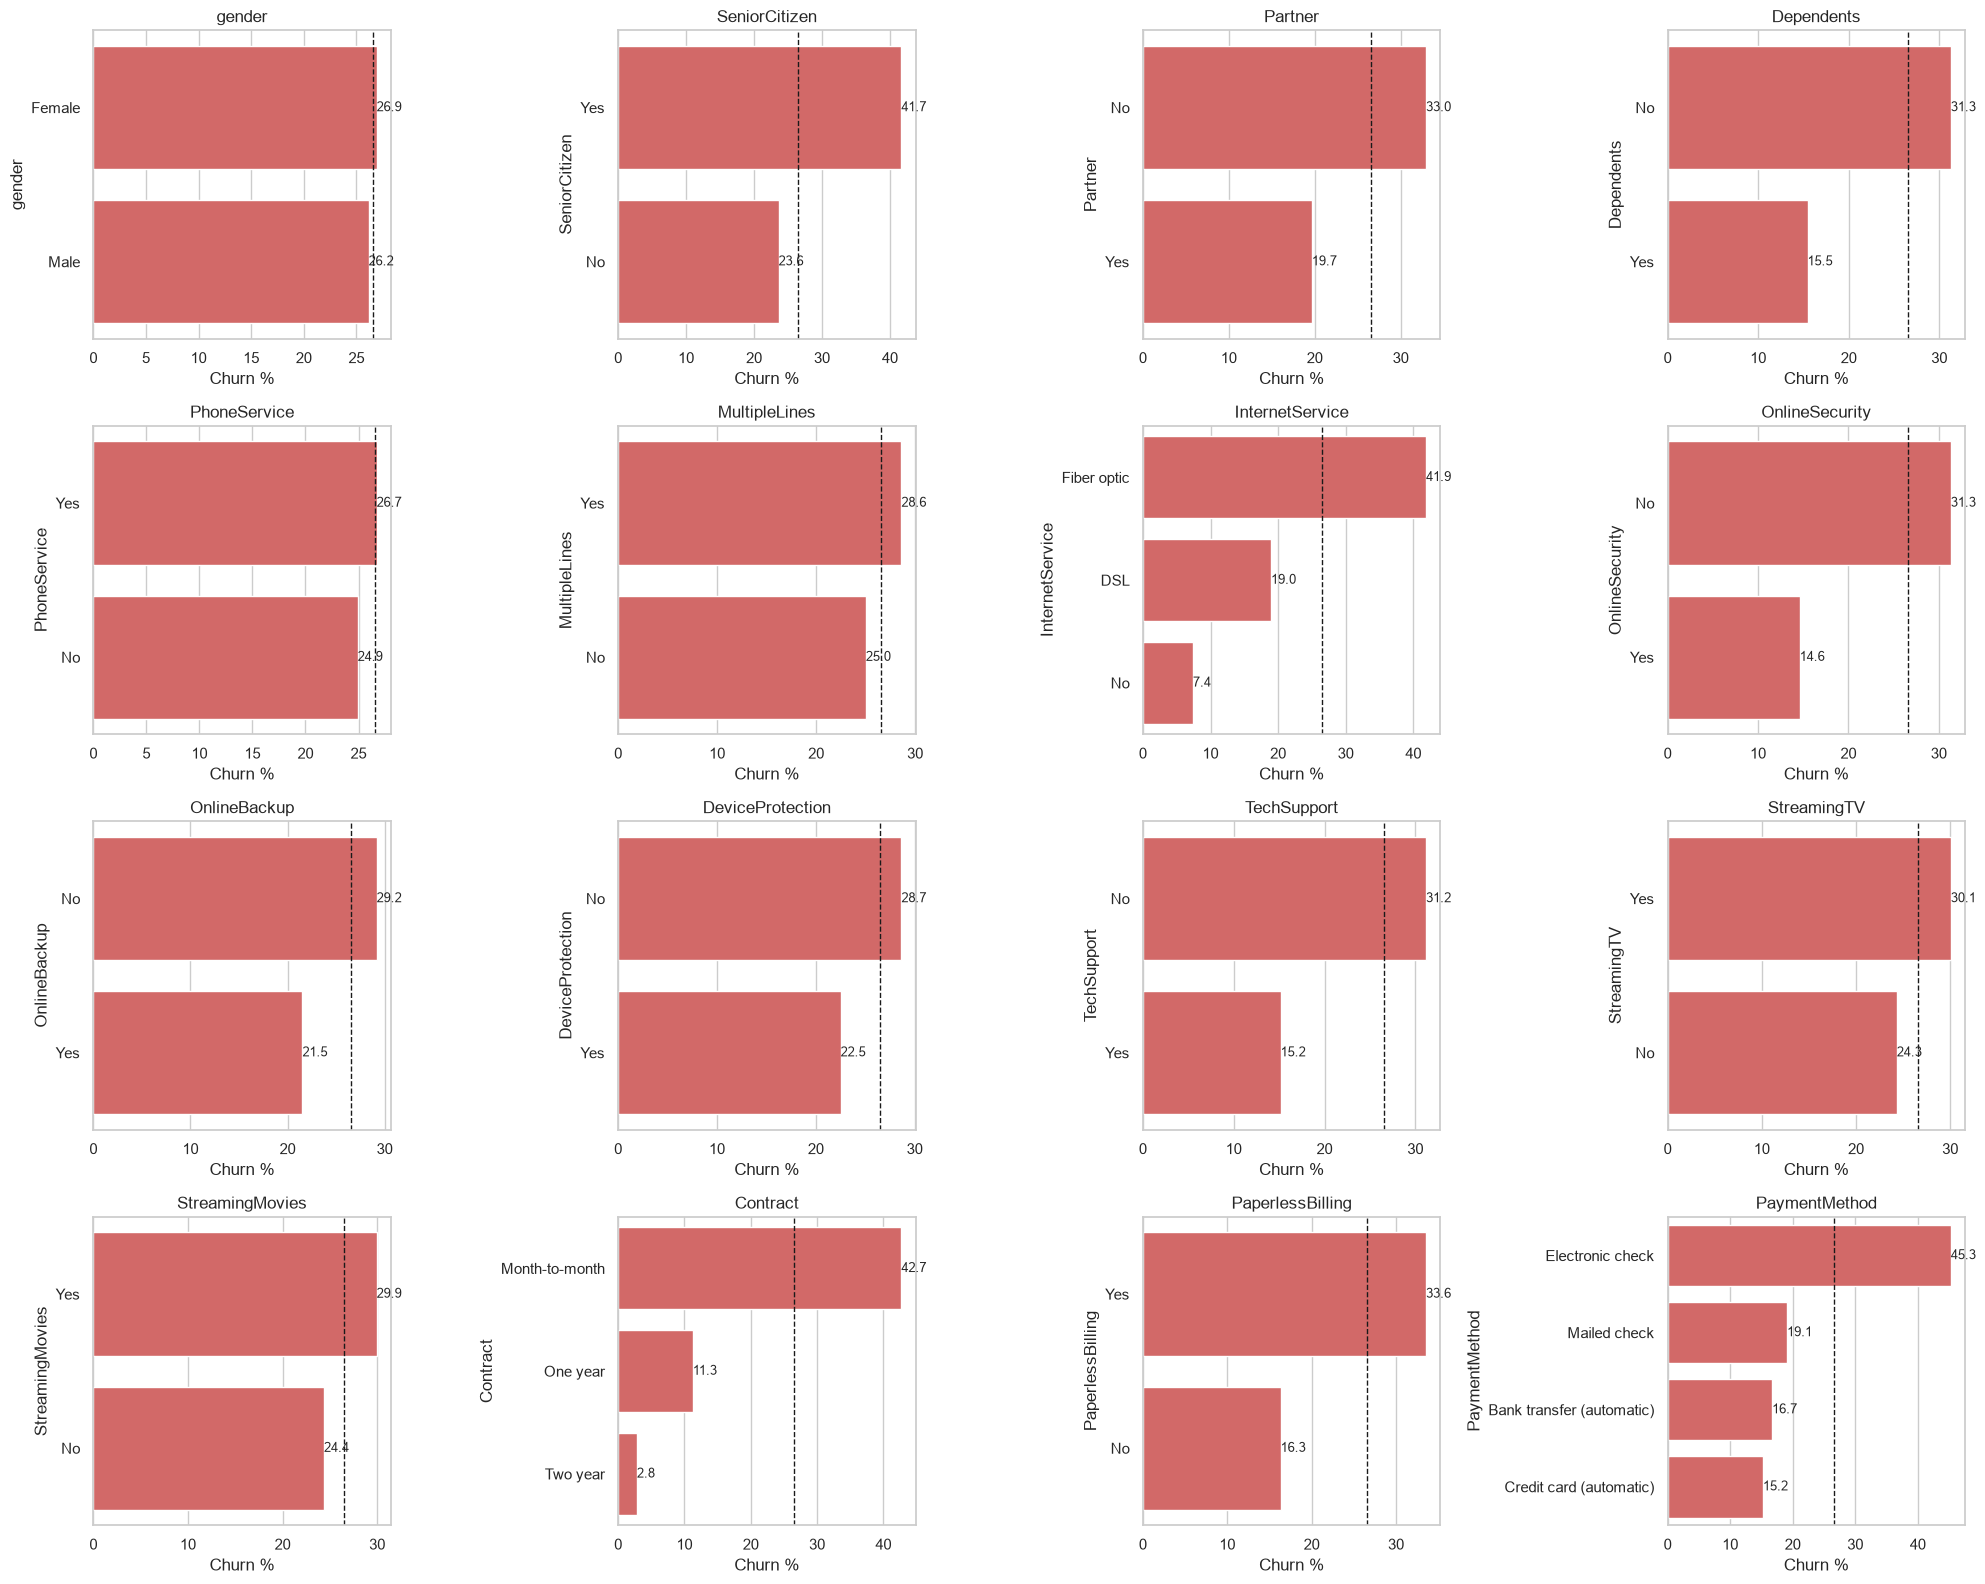

In [12]:
cat_cols = [c for c in df.select_dtypes('object').columns if c != 'Churn']
print(cat_cols)
fig, axes = plt.subplots(4, 4, figsize=(20,16)); axes = axes.ravel()
for i, c in enumerate(cat_cols):
    r = df.groupby(c)['ChurnFlag'].mean().mul(100).sort_values(ascending=False)
    sns.barplot(x=r.values, y=r.index, color='#E45756', ax=axes[i]); axes[i].set_title(c); axes[i].set_xlabel('Churn %')
    axes[i].axvline(df.ChurnFlag.mean()*100, color='k', ls='--', lw=1)
    for p in axes[i].patches: axes[i].annotate(f'{p.get_width():.1f}', (p.get_width(), p.get_y()+p.get_height()/2), va='center', fontsize=9)
for j in range(len(cat_cols), len(axes)): axes[j].axis('off')
save('04_categorical')

### EDA 5 — Key drivers in detail

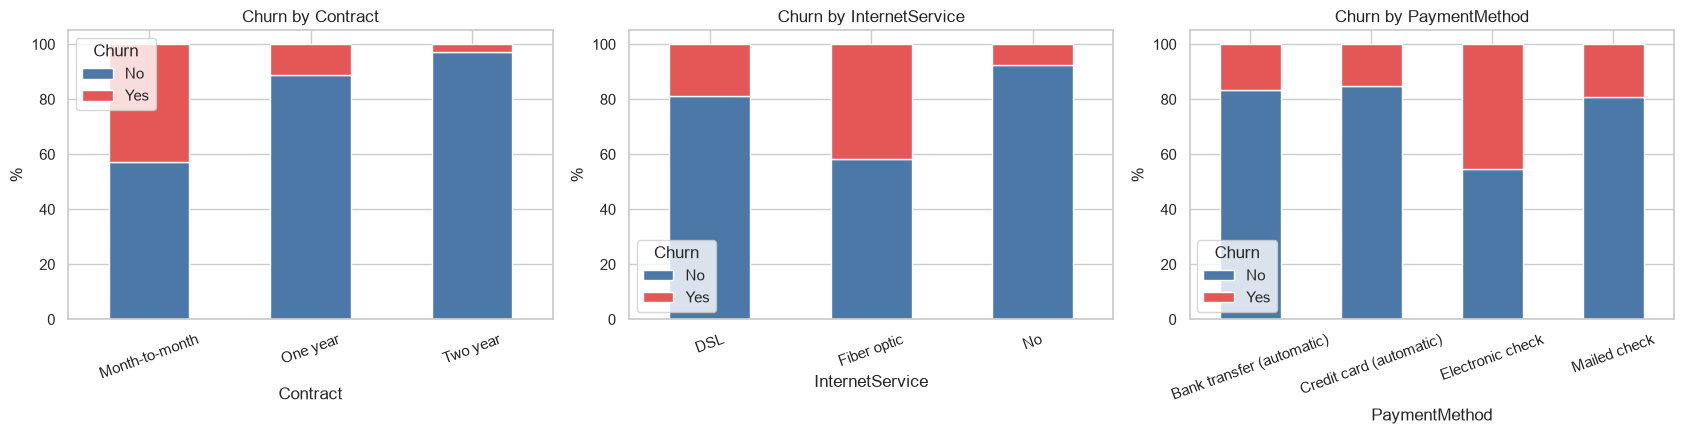

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(17,4.5))
for a, c in zip(ax, ['Contract','InternetService','PaymentMethod']):
    ct = pd.crosstab(df[c], df.Churn, normalize='index')*100
    ct[['No','Yes']].plot(kind='bar', stacked=True, color=[PAL['No'], PAL['Yes']], ax=a)
    a.set_title(f'Churn by {c}'); a.set_ylabel('%'); a.tick_params(axis='x', rotation=20)
save('05_key_drivers')

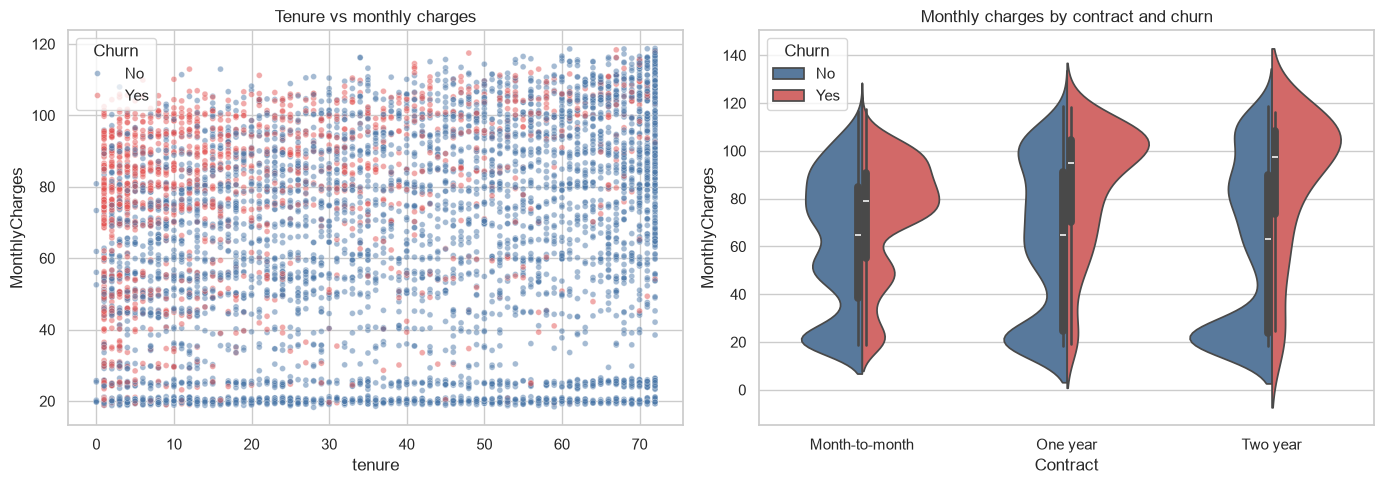

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', palette=PAL, alpha=.5, s=18, ax=ax[0]); ax[0].set_title('Tenure vs monthly charges')
sns.violinplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn', split=True, palette=PAL, ax=ax[1]); ax[1].set_title('Monthly charges by contract and churn')
save('06_tenure_charges')

ProtectionCount
0    56.7
1    38.9
2    23.8
3    12.4
4     5.3
Name: ChurnFlag, dtype: float64

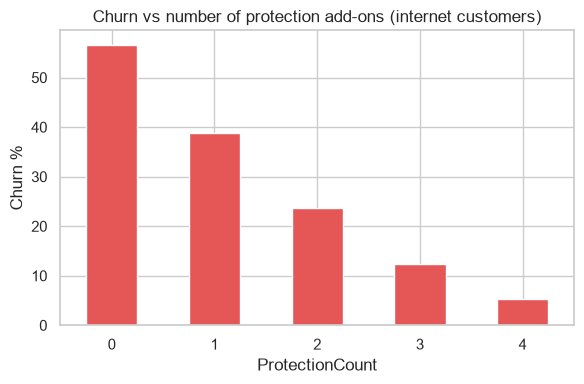

In [15]:
# Services add-on count vs churn (protective services)
prot = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']
df['ProtectionCount'] = (df[prot]=='Yes').sum(axis=1)
r = df[df.InternetService!='No'].groupby('ProtectionCount')['ChurnFlag'].mean().mul(100)
ax = r.plot(kind='bar', color='#E45756', figsize=(6,4)); ax.set_ylabel('Churn %'); ax.set_title('Churn vs number of protection add-ons (internet customers)')
plt.xticks(rotation=0); save('07_protection'); r.round(1)

### EDA 6 — Statistical association with churn

,feature,chi2,p_value,cramers_v
13,Contract,1184.5966,0.0000,0.4101
6,InternetService,732.3096,0.0000,0.3225
15,PaymentMethod,648.1423,0.0000,0.3034
14,PaperlessBilling,258.2776,0.0000,0.1915
7,OnlineSecurity,205.6331,0.0000,0.1709
10,TechSupport,190.1668,0.0000,0.1643
3,Dependents,189.1292,0.0000,0.1639
1,SeniorCitizen,159.4263,0.0000,0.1505
2,Partner,158.7334,0.0000,0.1501
8,OnlineBackup,47.2609,0.0000,0.0819


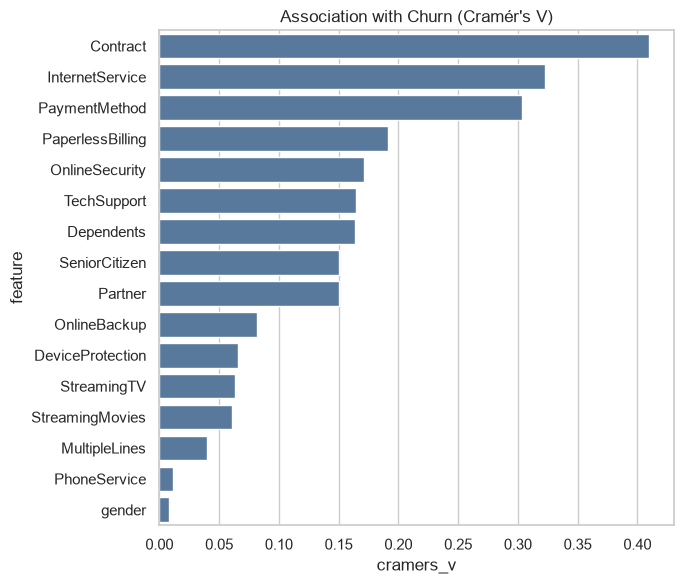

In [16]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y); chi2 = stats.chi2_contingency(ct)[0]; n = ct.values.sum()
    return np.sqrt(chi2/(n*(min(ct.shape)-1)))
res = []
for c in cat_cols:
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df[c], df.Churn))
    res.append((c, chi2, p, cramers_v(df[c], df.Churn)))
assoc = pd.DataFrame(res, columns=['feature','chi2','p_value','cramers_v']).sort_values('cramers_v', ascending=False)
display(assoc.round(4))
plt.figure(figsize=(7,6)); sns.barplot(data=assoc, y='feature', x='cramers_v', color='#4C78A8'); plt.title("Association with Churn (Cramér's V)")
save('08_cramers_v')

`Contract` (V=0.41), `InternetService` (0.32) and `PaymentMethod` (0.30) show the strongest association, followed by `PaperlessBilling`, `OnlineSecurity` and `TechSupport`. `gender` (p=0.49) and `PhoneService` (p=0.34) are not significantly related to churn.

### EDA 7 — Correlation heatmap

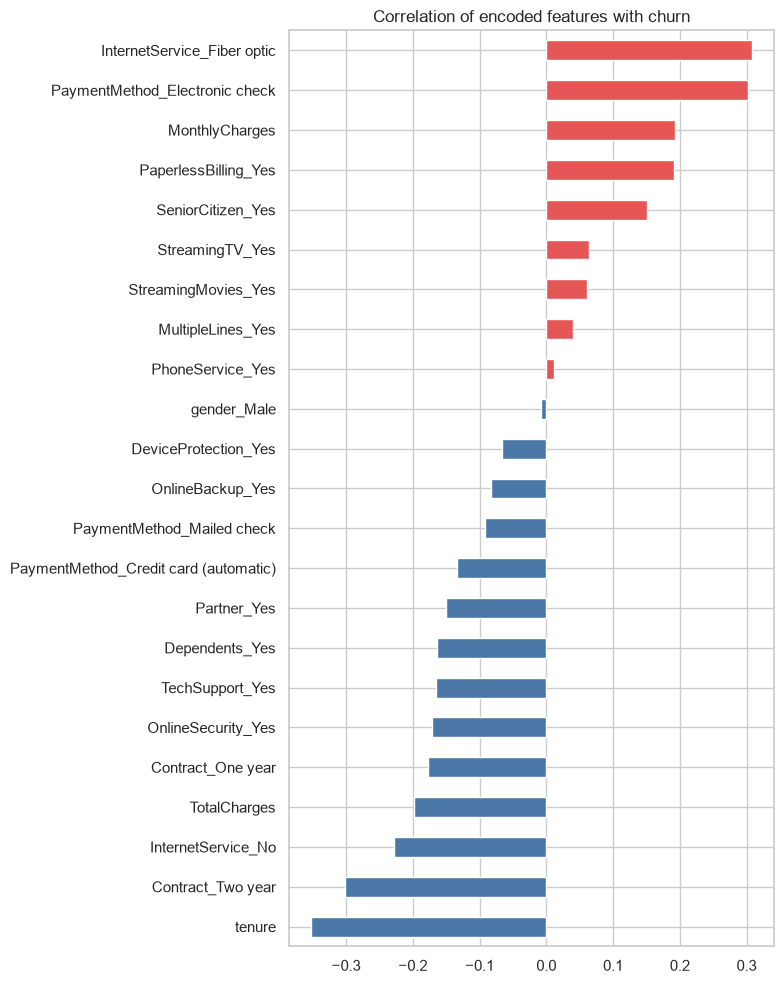

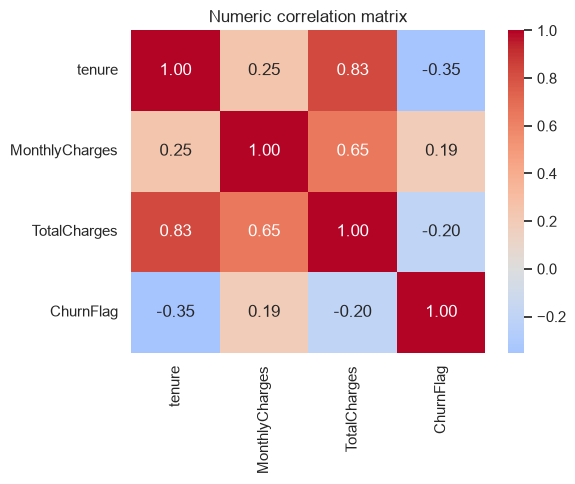

In [17]:
enc = pd.get_dummies(df.drop(columns=['Churn','TenureBand','ProtectionCount']), drop_first=True).astype(float)
corr = enc.corr()['ChurnFlag'].drop('ChurnFlag').sort_values()
plt.figure(figsize=(8,10)); corr.plot(kind='barh', color=np.where(corr>0,'#E45756','#4C78A8')); plt.title('Correlation of encoded features with churn'); save('09_corr_target')
plt.figure(figsize=(6,5)); sns.heatmap(df[num_cols+['ChurnFlag']].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f'); plt.title('Numeric correlation matrix'); save('10_corr_matrix')

**EDA summary**
- Churn risk is highest for **month-to-month contracts**, **fiber-optic internet**, **electronic-check payment**, **short tenure** and **no security/tech-support add-ons**.
- Two-year contracts, long tenure, and customers with several protection add-ons churn rarely.
- `TotalCharges` is strongly correlated with `tenure` (multicollinearity), so tree models or regularised logistic regression are sensible.
- Gender, and phone service have little relation to churn.

## Step 4 — Train a model
### 4.1 Features and train/test split (80/20, stratified)

In [18]:
model_df = df.drop(columns=['Churn','TenureBand','ProtectionCount'])
X, y = model_df.drop(columns='ChurnFlag'), model_df.ChurnFlag
num_f = ['tenure','MonthlyCharges','TotalCharges']; cat_f = [c for c in X.columns if c not in num_f]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Churn rate train/test: %.3f / %.3f' % (y_train.mean(), y_test.mean()))

Train: (5634, 19)  Test: (1409, 19)
Churn rate train/test: 0.265 / 0.265


### 4.2 Model parameters
Preprocessing: **StandardScaler** for numeric features, **one-hot encoding** (`drop='first'`) for categoricals, wrapped in a `Pipeline` so scaling/encoding are learned on the training data only (no leakage). Imbalance is handled with class weights.

| Model | Key parameters |
|---|---|
| Logistic Regression | `C=1.0`, `penalty='l2'`, `class_weight='balanced'`, `max_iter=1000` |
| Random Forest | `n_estimators=300`, `max_depth=8`, `min_samples_leaf=5`, `class_weight='balanced'` |
| Gradient Boosting | `n_estimators=200`, `learning_rate=0.05`, `max_depth=3`, balanced sample weights |

In [19]:
pre = ColumnTransformer([('num', StandardScaler(), num_f),
                         ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_f)])
models = {
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=RS),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5, class_weight='balanced', random_state=RS, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RS),
}
pipes = {}
for name, m in models.items():
    p = Pipeline([('pre', pre), ('clf', m)])
    if name == 'Gradient Boosting':
        p.fit(X_train, y_train, clf__sample_weight=compute_sample_weight('balanced', y_train))
    else:
        p.fit(X_train, y_train)
    pipes[name] = p
    print('trained', name)

trained Logistic Regression


trained Random Forest


trained Gradient Boosting


## Step 5 — Evaluate the model
Classification metrics on the held-out 20% test set (threshold 0.5).

In [20]:
rows = []
for name, p in pipes.items():
    pred, proba = p.predict(X_test), p.predict_proba(X_test)[:,1]
    rows.append(dict(Model=name, Accuracy=accuracy_score(y_test,pred), Precision=precision_score(y_test,pred),
                     Recall=recall_score(y_test,pred), F1=f1_score(y_test,pred), ROC_AUC=roc_auc_score(y_test,proba)))
results = pd.DataFrame(rows).set_index('Model').round(4)
results.to_csv('model_results.csv'); results

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.7402,0.5069,0.7861,0.6164,0.8419
Random Forest,0.7523,0.5219,0.7968,0.6307,0.8457
Gradient Boosting,0.7473,0.5154,0.8048,0.6284,0.8432


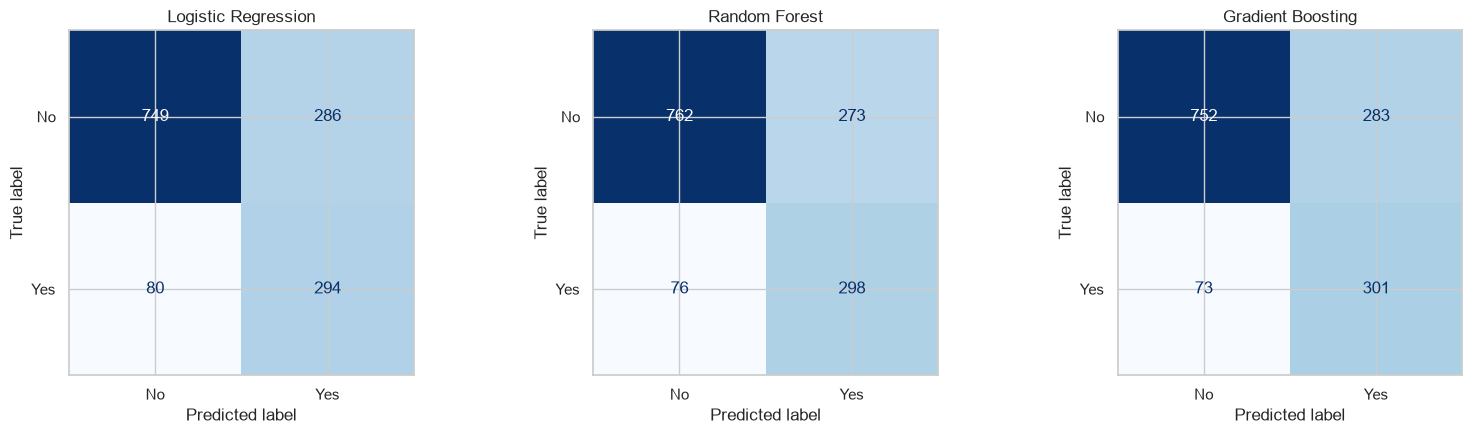

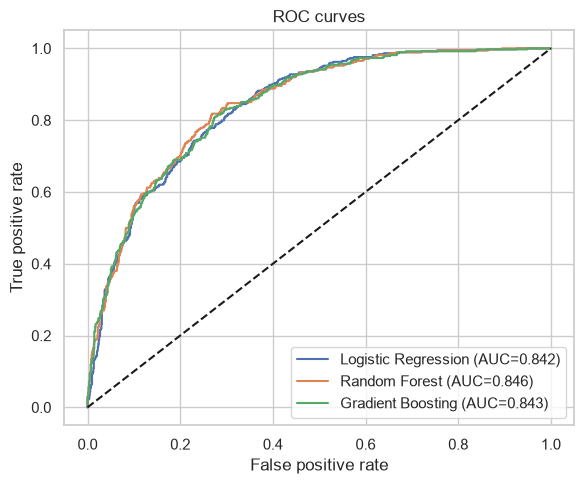

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(16,4.5))
for a, (name, p) in zip(ax, pipes.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p.predict(X_test)), display_labels=['No','Yes']).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(name)
save('11_confusion')
plt.figure(figsize=(6,5))
for name, p in pipes.items():
    fpr, tpr, _ = roc_curve(y_test, p.predict_proba(X_test)[:,1]); plt.plot(fpr, tpr, label=f"{name} (AUC={results.loc[name,'ROC_AUC']:.3f})")
plt.plot([0,1],[0,1],'k--'); plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.title('ROC curves'); plt.legend(loc='lower right'); save('12_roc')

### 5.1 Light hyperparameter tuning (5-fold stratified CV, scoring = ROC-AUC)

In [22]:
lr_pipe = Pipeline([('pre', pre), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RS))])
gs = GridSearchCV(lr_pipe, {'clf__C': [0.01, 0.1, 1, 10]}, scoring='roc_auc', cv=StratifiedKFold(5, shuffle=True, random_state=RS))
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_, '| CV ROC-AUC: %.4f' % gs.best_score_)
best = gs.best_estimator_
pred, proba = best.predict(X_test), best.predict_proba(X_test)[:,1]
tuned = dict(Accuracy=accuracy_score(y_test,pred), Precision=precision_score(y_test,pred), Recall=recall_score(y_test,pred), F1=f1_score(y_test,pred), ROC_AUC=roc_auc_score(y_test,proba))
results.loc['Logistic Regression (tuned)'] = pd.Series(tuned).round(4)
results.to_csv('model_results.csv'); results

Best params: {'clf__C': 10} | CV ROC-AUC: 0.8462


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.7402,0.5069,0.7861,0.6164,0.8419
Random Forest,0.7523,0.5219,0.7968,0.6307,0.8457
Gradient Boosting,0.7473,0.5154,0.8048,0.6284,0.8432
Logistic Regression (tuned),0.7402,0.5069,0.7834,0.6155,0.8409


In [23]:
print(classification_report(y_test, best.predict(X_test), target_names=['No churn','Churn']))

              precision    recall  f1-score   support

    No churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### 5.2 What drives the predictions?

InternetService_Fiber optic    2.296548
StreamingMovies_Yes            0.850653
StreamingTV_Yes                0.825461
PhoneService_Yes               0.689707
MultipleLines_Yes              0.541679
TotalCharges                   0.517704
dtype: float64

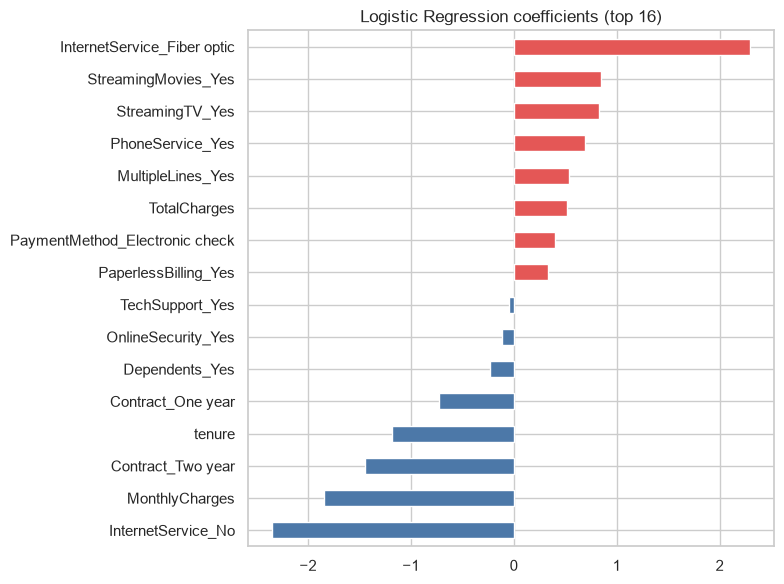

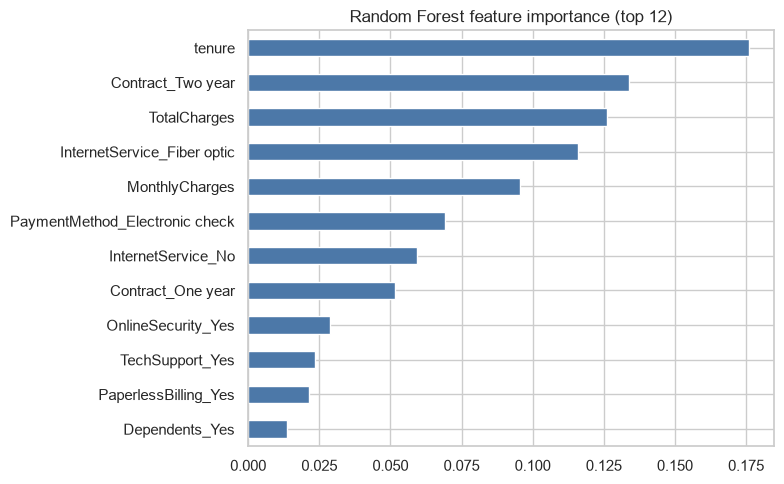

In [24]:
names = best.named_steps['pre'].get_feature_names_out()
coef = pd.Series(best.named_steps['clf'].coef_[0], index=[n.split('__')[1] for n in names]).sort_values()
top = pd.concat([coef.head(8), coef.tail(8)])
plt.figure(figsize=(8,6)); top.plot(kind='barh', color=np.where(top>0,'#E45756','#4C78A8')); plt.title('Logistic Regression coefficients (top 16)'); save('13_coef')
rf = pipes['Random Forest']; imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=[n.split('__')[1] for n in rf.named_steps['pre'].get_feature_names_out()]).sort_values().tail(12)
plt.figure(figsize=(8,5)); imp.plot(kind='barh', color='#4C78A8'); plt.title('Random Forest feature importance (top 12)'); save('14_rf_imp')
coef.sort_values(ascending=False).head(6)

## Step 6 — Use the model to predict on new (unseen) data
The 20% test split was never seen during training or tuning. Below, churn probabilities for sample test customers and a hand-made new customer.

In [25]:
sample = X_test.head(8).copy()
sample['P(churn)'] = best.predict_proba(sample)[:,1].round(3)
sample['Predicted'] = np.where(sample['P(churn)']>=0.5,'Yes','No')
sample['Actual'] = y_test.head(8).map({0:'No',1:'Yes'})
sample[['tenure','Contract','InternetService','PaymentMethod','MonthlyCharges','P(churn)','Predicted','Actual']]

,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,P(churn),Predicted,Actual
437,72,Two year,Fiber optic,Credit card (automatic),114.05,0.123,No,No
2280,8,Month-to-month,Fiber optic,Credit card (automatic),100.15,0.852,Yes,No
2235,41,One year,DSL,Credit card (automatic),78.35,0.130,No,No
4460,18,Month-to-month,Fiber optic,Electronic check,78.20,0.676,Yes,No
3761,72,Two year,DSL,Credit card (automatic),82.65,0.064,No,No
5748,21,Month-to-month,Fiber optic,Credit card (automatic),99.85,0.806,Yes,No
3568,21,Month-to-month,Fiber optic,Bank transfer (automatic),99.15,0.703,Yes,No
2976,19,Month-to-month,No,Credit card (automatic),24.10,0.299,No,No


In [26]:
new = pd.DataFrame([
 dict(gender='Female', SeniorCitizen='No', Partner='No', Dependents='No', tenure=2, PhoneService='Yes', MultipleLines='No', InternetService='Fiber optic',
      OnlineSecurity='No', OnlineBackup='No', DeviceProtection='No', TechSupport='No', StreamingTV='Yes', StreamingMovies='Yes', Contract='Month-to-month',
      PaperlessBilling='Yes', PaymentMethod='Electronic check', MonthlyCharges=95.0, TotalCharges=190.0),
 dict(gender='Male', SeniorCitizen='No', Partner='Yes', Dependents='Yes', tenure=60, PhoneService='Yes', MultipleLines='Yes', InternetService='DSL',
      OnlineSecurity='Yes', OnlineBackup='Yes', DeviceProtection='Yes', TechSupport='Yes', StreamingTV='No', StreamingMovies='No', Contract='Two year',
      PaperlessBilling='No', PaymentMethod='Bank transfer (automatic)', MonthlyCharges=65.0, TotalCharges=3900.0)])
new['P(churn)'] = best.predict_proba(new)[:,1].round(3)
new[['tenure','Contract','InternetService','PaymentMethod','P(churn)']]

,tenure,Contract,InternetService,PaymentMethod,P(churn)
0,2,Month-to-month,Fiber optic,Electronic check,0.874
1,60,Two year,DSL,Bank transfer (automatic),0.023


## Conclusion
- **Data quality:** only one issue — 11 blank `TotalCharges` (tenure 0), set to 0. No duplicates, no other missing values, no outliers.
- **EDA:** churn concentrates in new, month-to-month, fiber-optic, electronic-check customers without security/support add-ons.
- **Models:** all three models perform similarly (test ROC-AUC 0.842-0.846; Random Forest is marginally highest). The class-weighted models trade accuracy (about 74-75%) for high recall on churners (about 79-80%) at a precision of about 51-52%. Because the differences are tiny, Logistic Regression is a reasonable choice for its interpretability, while Random Forest is the best on raw metrics. Tuning C (best C=10) did not improve the test score.
- **Recommendation:** target month-to-month and early-tenure customers with contract-upgrade offers and bundle security/tech-support add-ons.